# Лабораторная работа №1. Разведочный анализ данных  
# 实验一：探索性数据分析（EDA）

**Датасет / 数据集:** Car Price Prediction  
**Источник / 数据来源:** https://www.kaggle.com/datasets/vijayaadithyanvg/car-price-predictionused-cars/data  
**Тип задачи / 任务类型:** регрессия / 回归  
**Целевая переменная / 目标变量:** `Selling_Price`

### Цель работы / 实验目的

**RU:** Изучить структуру и качество данных, выполнить очистку, удалить малочисленные подгруппы,
исследовать связи признаков с целевой переменной и сохранить очищенную выборку для следующих лабораторных работ.

**中文：** 在训练模型之前，先检查数据结构和质量，完成数据清洗，删除样本过少且会影响分析稳定性的小类，
研究特征与目标变量之间的关系，并保存清洗后的数据供后续实验使用。

# 1. Загрузка и знакомство с данными  
# 1. 数据加载与认识

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
root_candidates = [cwd, cwd.parent]
PROJECT_ROOT = next(
    (p for p in root_candidates if (p / "data" / "car_data.csv").exists()),
    cwd.parent
)

DATA_PATH = PROJECT_ROOT / "data" / "car_data.csv"
EDA_DIR = PROJECT_ROOT / "eda"
CLEAN_PATH = PROJECT_ROOT / "data" / "clean_data.pkl"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Не найден файл {DATA_PATH}. "
        "Скачайте датасет и сохраните его как data/car_data.csv."
    )

EDA_DIR.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(DATA_PATH)
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [2]:
print(f"Размер исходной выборки: {df.shape[0]} строк, {df.shape[1]} столбцов")

print("\nТипы данных:")
display(df.dtypes.rename("dtype").to_frame())

print("\nПропущенные значения:")
display(df.isna().sum().rename("missing").to_frame())

print("Полные дубликаты:", int(df.duplicated().sum()))

print("\nОсновные статистики:")
display(df.describe(include="all").T)

Размер исходной выборки: 301 строк, 9 столбцов

Типы данных:


,dtype
Car_Name,object
Year,int64
Selling_Price,float64
Present_Price,float64
Driven_kms,int64
Fuel_Type,object
Selling_type,object
Transmission,object
Owner,int64



Пропущенные значения:


,missing
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


Полные дубликаты: 2

Основные статистики:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.642584,0.32,1.2,6.4,9.9,92.6
Driven_kms,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Selling_type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


### Типы признаков / 特征类型

- **Целевая переменная / 目标变量:** `Selling_Price`
- **Числовые признаки / 数值特征:** `Year`, `Present_Price`, `Driven_kms`
- **Дискретный числовой признак / 离散数值特征:** `Owner`
- **Категориальные признаки / 类别特征:** `Car_Name`, `Fuel_Type`, `Selling_type`, `Transmission`

In [3]:
categorical_cols = ["Car_Name", "Fuel_Type", "Selling_type", "Transmission"]

category_summary = pd.DataFrame({
    "unique_values": [df[col].nunique() for col in categorical_cols],
    "most_frequent": [df[col].mode().iloc[0] for col in categorical_cols]
}, index=categorical_cols)

display(category_summary)

for col in ["Fuel_Type", "Selling_type", "Transmission", "Owner"]:
    print(f"\n{col}:")
    display(df[col].value_counts(dropna=False).to_frame("count"))

,unique_values,most_frequent
Car_Name,98,city
Fuel_Type,3,Petrol
Selling_type,2,Dealer
Transmission,2,Manual



Fuel_Type:


,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2



Selling_type:


,count
Selling_type,
Dealer,195
Individual,106



Transmission:


,count
Transmission,
Manual,261
Automatic,40



Owner:


,count
Owner,
0,290
1,10
3,1


### Промежуточный вывод / 阶段性结论

**RU:** Исходно в данных было **301 строк**. Пропусков нет, найдено **2 полных дубликата**.
Категория `CNG` представлена только двумя наблюдениями, а значения `Owner = 1` и `Owner = 3`
также встречаются редко.

**中文：** 原始数据共有 **301 条记录**。没有缺失值，发现 **2 条完全重复记录**。
`CNG` 类别只有 2 个样本，`Owner = 1` 和 `Owner = 3` 的样本量也很少。

# 2. Очистка данных  
# 2. 数据清洗

In [4]:
n_before = len(df)

df = df.drop_duplicates().copy()
duplicates_removed = n_before - len(df)

cng_removed = int((df["Fuel_Type"] == "CNG").sum())
df = df[df["Fuel_Type"] != "CNG"].copy()

owner_1_removed = int((df["Owner"] == 1).sum())
owner_3_removed = int((df["Owner"] == 3).sum())
df = df[~df["Owner"].isin([1, 3])].copy()

for col in categorical_cols:
    df[col] = df[col].astype("category")

validity_checks = pd.Series({
    "Selling_Price <= 0": int((df["Selling_Price"] <= 0).sum()),
    "Present_Price <= 0": int((df["Present_Price"] <= 0).sum()),
    "Selling_Price > Present_Price": int((df["Selling_Price"] > df["Present_Price"]).sum()),
    "Driven_kms < 0": int((df["Driven_kms"] < 0).sum()),
    "Owner < 0": int((df["Owner"] < 0).sum()),
}, name="invalid_rows")

print("Удалено полных дубликатов:", duplicates_removed)
print("Удалено объектов Fuel_Type = CNG:", cng_removed)
print("Удалено объектов Owner = 1:", owner_1_removed)
print("Удалено объектов Owner = 3:", owner_3_removed)
print("Итоговый размер после очистки:", df.shape)
print("Пропусков после очистки:", int(df.isna().sum().sum()))
display(validity_checks.to_frame())

Удалено полных дубликатов: 2
Удалено объектов Fuel_Type = CNG: 2
Удалено объектов Owner = 1: 10
Удалено объектов Owner = 3: 1
Итоговый размер после очистки: (286, 9)
Пропусков после очистки: 0


,invalid_rows
Selling_Price <= 0,0
Present_Price <= 0,0
Selling_Price > Present_Price,0
Driven_kms < 0,0
Owner < 0,0


### Вывод по очистке / 数据清洗结论

**RU:** Удалены **2 полных дубликата**, затем исключены **2 объекта** с `Fuel_Type = CNG`,
а также **10 объекта** с `Owner = 1` и **1 объекта** с `Owner = 3`.
После очистки осталось **286 объектов**.

**中文：** 清洗阶段删除了 **2 条完全重复记录**，
随后剔除了 `Fuel_Type = CNG` 的 **2 条**记录，
以及 `Owner = 1` 的 **10 条**和 `Owner = 3` 的 **1 条**记录。
最终剩余 **286 条样本**。

# 3. Создание нового признака  
# 3. 构造新特征

In [5]:
reference_year = int(df["Year"].max())
df["Car_Age"] = reference_year - df["Year"]

print("Самый новый год в выборке:", reference_year)
display(df[["Year", "Car_Age"]].head())

Самый новый год в выборке: 2018


,Year,Car_Age
0,2014,4
1,2013,5
2,2017,1
3,2011,7
4,2014,4


### Почему `Car_Age`? / 为什么构造 `Car_Age`？

**RU:** `Car_Age` удобнее интерпретировать, чем сам календарный год: чем больше значение, тем старше автомобиль.

**中文：** `Car_Age` 比直接使用年份更直观：数值越大，汽车越旧。

# 4. Анализ признаков для модели  
# 4. 特征分析与可视化

## График 1. Распределение `Selling_Price`  
## 图 1：目标变量 `Selling_Price` 的分布

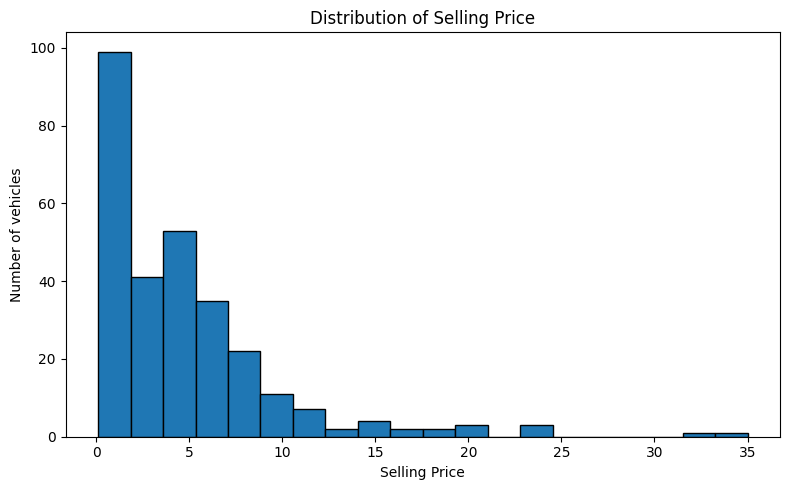

Mean: 4.7
Median: 3.75


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["Selling_Price"], bins=20, edgecolor="black")
ax.set_title("Distribution of Selling Price")
ax.set_xlabel("Selling Price")
ax.set_ylabel("Number of vehicles")
fig.tight_layout()
fig.savefig(EDA_DIR / "graph1_selling_price_distribution.png", dpi=150)
plt.show()

print("Mean:", round(df["Selling_Price"].mean(), 2))
print("Median:", round(df["Selling_Price"].median(), 2))

### Вывод / 结论

**RU:** Распределение `Selling_Price` правосторонне асимметрично.
Среднее значение выше медианы, что указывает на наличие более дорогих автомобилей.

**中文：** `Selling_Price` 呈右偏分布，平均值高于中位数，说明样本中存在一些更高价的车辆。

## График 2. `Present_Price` и `Selling_Price`  
## 图 2：`Present_Price` 与 `Selling_Price` 的关系

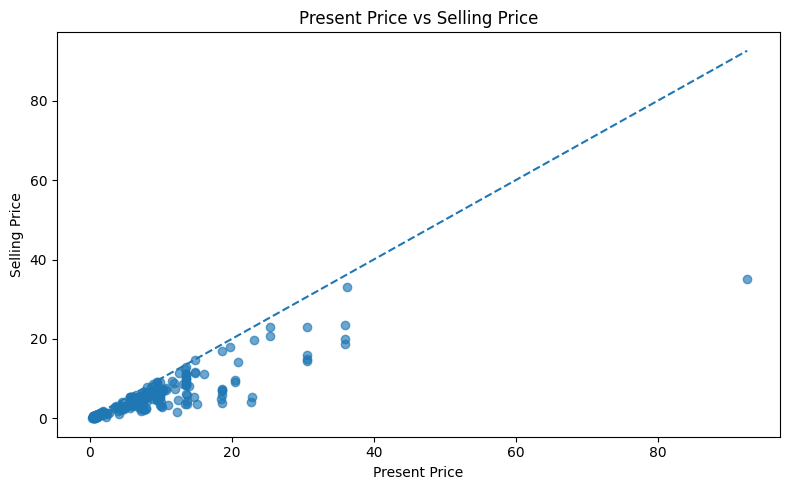

Correlation: 0.884
Количество объектов выше линии y = x: 0


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["Present_Price"], df["Selling_Price"], alpha=0.65)

max_val = max(df["Present_Price"].max(), df["Selling_Price"].max())
ax.plot([0, max_val], [0, max_val], linestyle="--")

ax.set_title("Present Price vs Selling Price")
ax.set_xlabel("Present Price")
ax.set_ylabel("Selling Price")
fig.tight_layout()
fig.savefig(EDA_DIR / "graph2_present_vs_selling.png", dpi=150)
plt.show()

corr_present = df["Present_Price"].corr(df["Selling_Price"])
above_line = int((df["Selling_Price"] > df["Present_Price"]).sum())

print("Correlation:", round(corr_present, 3))
print("Количество объектов выше линии y = x:", above_line)

### Вывод / 结论

**RU:** Между `Present_Price` и `Selling_Price` сохраняется сильная положительная связь.
Линия `y = x` позволяет визуально выделить автомобили, у которых `Selling_Price > Present_Price`.

**中文：** `Present_Price` 与 `Selling_Price` 仍然存在较强的正相关。
加入 `y = x` 参考线后，可以直观看出哪些车辆满足 `Selling_Price > Present_Price`。

## График 3. Цена по типу топлива  
## 图 3：不同燃料类型的售价

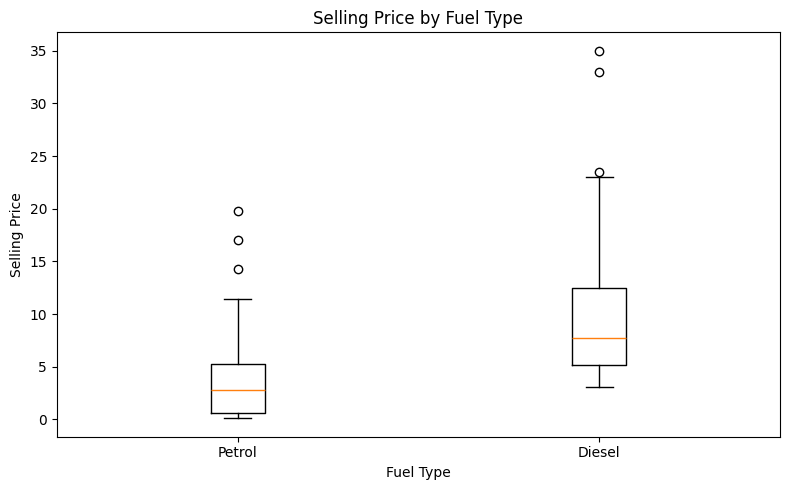

,count,mean,median
Fuel_Type,,,
Diesel,57,10.22,7.75
Petrol,229,3.32,2.75


In [8]:
fuel_order = ["Petrol", "Diesel"]
fuel_data = [
    df.loc[df["Fuel_Type"] == fuel, "Selling_Price"]
    for fuel in fuel_order
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(fuel_data, tick_labels=fuel_order)
ax.set_title("Selling Price by Fuel Type")
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Selling Price")
fig.tight_layout()
fig.savefig(EDA_DIR / "graph3_fuel_type_boxplot.png", dpi=150)
plt.show()

display(
    df.groupby("Fuel_Type", observed=True)["Selling_Price"]
      .agg(["count", "mean", "median"])
      .round(2)
)

### Вывод / 结论

**RU:** После удаления `CNG` сравнение между `Petrol` и `Diesel` стало более устойчивым.
В этой выборке дизельные автомобили имеют более высокую типичную цену продажи.

**中文：** 删除 `CNG` 后，`Petrol` 和 `Diesel` 的比较更稳定。
在该样本中，柴油车的典型售价更高。

## График 4. Цена по типу коробки передач  
## 图 4：不同变速箱类型的售价

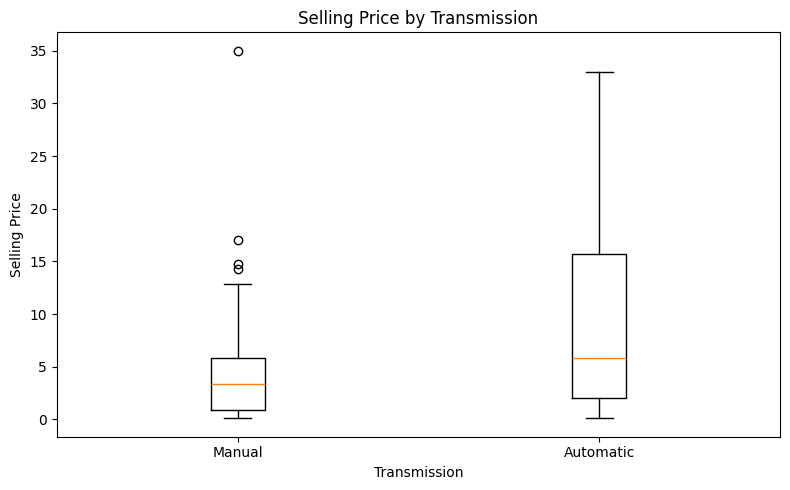

,count,mean,median
Transmission,,,
Automatic,38,9.24,5.80
Manual,248,4.00,3.35


In [9]:
transmission_order = ["Manual", "Automatic"]
transmission_data = [
    df.loc[df["Transmission"] == transmission, "Selling_Price"]
    for transmission in transmission_order
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(transmission_data, tick_labels=transmission_order)
ax.set_title("Selling Price by Transmission")
ax.set_xlabel("Transmission")
ax.set_ylabel("Selling Price")
fig.tight_layout()
fig.savefig(EDA_DIR / "graph4_transmission_boxplot.png", dpi=150)
plt.show()

display(
    df.groupby("Transmission", observed=True)["Selling_Price"]
      .agg(["count", "mean", "median"])
      .round(2)
)

### Вывод / 结论

**RU:** Автомобили с автоматической коробкой стоят дороже по средней и медианной цене.

**中文：** 自动挡汽车在平均价格和中位价格上都更高。

## График 5. Цена по типу продавца  
## 图 5：不同销售者类型的售价

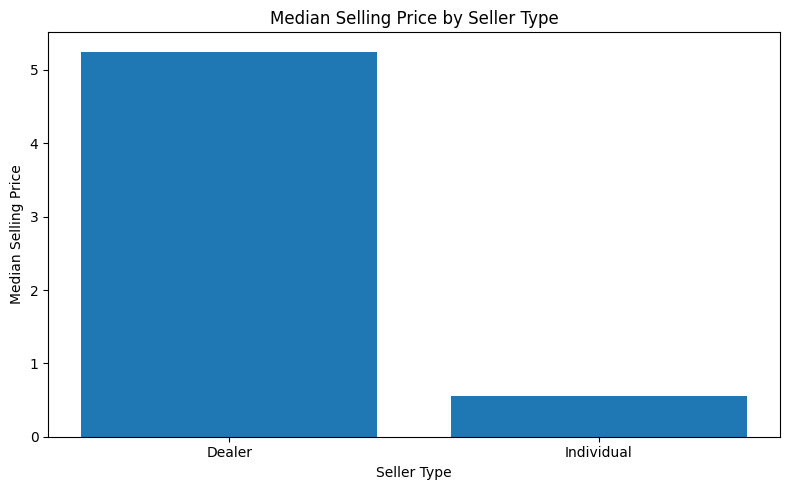

,count,mean,median
Selling_type,,,
Dealer,187,6.72,5.25
Individual,99,0.88,0.55


In [10]:
seller_stats = (
    df.groupby("Selling_type", observed=True)["Selling_Price"]
      .agg(["count", "mean", "median"])
      .round(2)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(seller_stats.index, seller_stats["median"])
ax.set_title("Median Selling Price by Seller Type")
ax.set_xlabel("Seller Type")
ax.set_ylabel("Median Selling Price")
fig.tight_layout()
fig.savefig(EDA_DIR / "graph5_seller_type_median.png", dpi=150)
plt.show()

display(seller_stats)

### Вывод / 结论

**RU:** В группе `Dealer` медианная цена выше, чем в группе `Individual`.
Это статистическое отличие, а не доказательство причинной зависимости.

**中文：** `Dealer` 组的中位售价高于 `Individual` 组，但这只是统计差异，不代表因果关系。

## График 6. Матрица корреляций  
## 图 6：相关系数矩阵

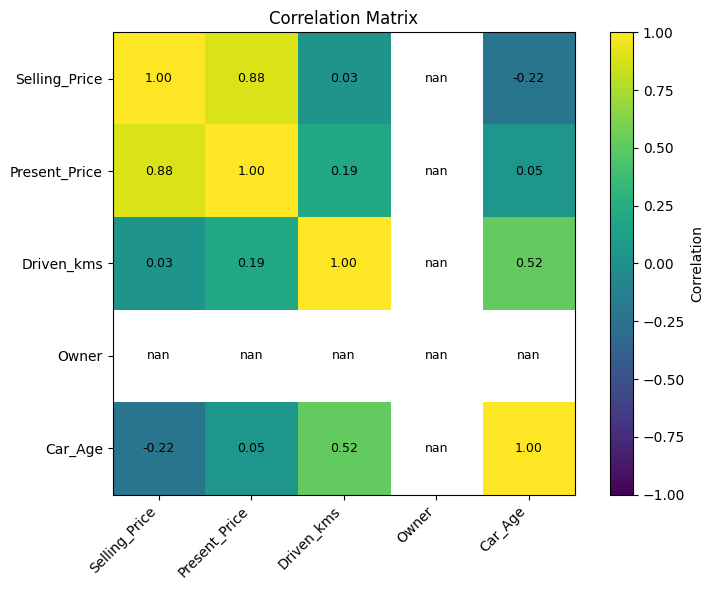

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age
Selling_Price,1.000,0.884,0.031,NaN,-0.220
Present_Price,0.884,1.000,0.190,NaN,0.054
Driven_kms,0.031,0.190,1.000,NaN,0.523
Owner,NaN,NaN,NaN,NaN,NaN
Car_Age,-0.220,0.054,0.523,NaN,1.000


In [11]:
corr_cols = ["Selling_Price", "Present_Price", "Driven_kms", "Owner", "Car_Age"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)), corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Matrix")
fig.tight_layout()
fig.savefig(EDA_DIR / "graph6_correlation_matrix.png", dpi=150)
plt.show()

display(corr.round(3))

### Вывод / 结论

**RU:** Самая сильная линейная связь с `Selling_Price` остается у `Present_Price`.
`Car_Age` отрицательно связан с ценой.

**中文：** 与 `Selling_Price` 线性关系最强的仍是 `Present_Price`；
`Car_Age` 与售价呈负相关。

## График 7. Интерактивный график Bokeh  
## 图 7：Bokeh 交互式散点图

In [12]:
from bokeh.plotting import figure, show, output_file, save
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.io import output_notebook
from bokeh.resources import INLINE

def make_interactive_plot():
    source = ColumnDataSource(df)

    p = figure(
        width=900,
        height=550,
        title="Interactive: Present Price vs Selling Price",
        x_axis_label="Present Price",
        y_axis_label="Selling Price",
        tools="pan,wheel_zoom,box_zoom,reset,save"
    )

    p.scatter(
        x="Present_Price",
        y="Selling_Price",
        source=source,
        size=7,
        alpha=0.65
    )

    max_val = max(df["Present_Price"].max(), df["Selling_Price"].max())
    p.line([0, max_val], [0, max_val], line_dash="dashed")

    p.add_tools(HoverTool(tooltips=[
        ("Car", "@Car_Name"),
        ("Year", "@Year"),
        ("Present price", "@Present_Price"),
        ("Selling price", "@Selling_Price"),
        ("Driven kms", "@Driven_kms"),
        ("Fuel", "@Fuel_Type"),
        ("Transmission", "@Transmission"),
        ("Owner", "@Owner"),
    ]))

    return p

interactive_path = EDA_DIR / "graph7_interactive.html"
output_file(interactive_path, title="Car Price Interactive EDA")
save(make_interactive_plot(), resources=INLINE)

output_notebook(resources=INLINE)
show(make_interactive_plot())

print("Интерактивный график сохранен:", interactive_path)

Интерактивный график сохранен: /mnt/data/lab1_car_price/eda/graph7_interactive.html


### Вывод / 结论

**RU:** В интерактивной версии также добавлена линия `y = x`, поэтому можно находить автомобили
с `Selling_Price > Present_Price` и одновременно просматривать их характеристики.

**中文：** 交互图中同样加入了 `y = x` 参考线，因此可以识别 `Selling_Price > Present_Price`
的车辆，并同时查看这些样本的详细属性。

# 5. Сохранение финального датасета  
# 5. 保存最终清洗数据

In [13]:
df.to_pickle(CLEAN_PATH)

print("Очищенный датасет сохранен:", CLEAN_PATH)
print("Итоговый размер:", df.shape)

print("\nТипы данных финальной выборки:")
df.info()

Очищенный датасет сохранен: /mnt/data/lab1_car_price/data/clean_data.pkl
Итоговый размер: (286, 10)

Типы данных финальной выборки:
<class 'pandas.core.frame.DataFrame'>
Index: 286 entries, 0 to 300
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Car_Name       286 non-null    category
 1   Year           286 non-null    int64   
 2   Selling_Price  286 non-null    float64 
 3   Present_Price  286 non-null    float64 
 4   Driven_kms     286 non-null    int64   
 5   Fuel_Type      286 non-null    category
 6   Selling_type   286 non-null    category
 7   Transmission   286 non-null    category
 8   Owner          286 non-null    int64   
 9   Car_Age        286 non-null    int64   
dtypes: category(4), float64(2), int64(4)
memory usage: 19.9 KB


In [14]:
check_df = pd.read_pickle(CLEAN_PATH)

assert check_df.shape == df.shape
assert check_df.isna().sum().sum() == 0
assert check_df.duplicated().sum() == 0

print("Проверка сохраненного датасета пройдена.")

Проверка сохраненного датасета пройдена.


# 6. Итоговые выводы после EDA  
# 6. EDA 最终总结

### RU

В ходе работы:
- исходно было **301 строк**;
- удалены **2 полных дубликата**;
- исключена категория `Fuel_Type = CNG` (**2 объекта**);
- исключены подгруппы `Owner = 1` (**10 объекта**) и `Owner = 3` (**1 объекта**);
- после очистки осталось **286 объектов**;
- создан новый признак `Car_Age`;
- построено **6 статических графиков и 1 интерактивный график Bokeh**;
- в графики 2 и 7 добавлена линия `y = x` для выделения автомобилей, у которых `Selling_Price > Present_Price`;
- очищенная выборка сохранена в `data/clean_data.pkl`.

### 中文

本实验中：
- 原始数据共有 **301 条**；
- 删除 **2 条完全重复记录**；
- 剔除 `Fuel_Type = CNG` 类别（共 **2 条**）；
- 剔除 `Owner = 1`（共 **10 条**）和 `Owner = 3`（共 **1 条**）这两个小样本子类；
- 清洗后剩余 **286 条记录**；
- 构造了新特征 `Car_Age`；
- 绘制 **6 张静态图 + 1 张 Bokeh 交互图**；
- 在图 2 和图 7 中加入了 `y = x` 参考线，用于识别 `Selling_Price > Present_Price` 的车辆；
- 清洗后的数据保存为 `data/clean_data.pkl`。